# 02 : Completeness Assessment

## 1. Introduction

### The core question this notebook asks

Before explicitly tagging a settlement as genuinely "underserved" by health or
education facilities, it's worth asking a prior question: **is OSM's own
data actually complete enough in this area to trust that judgment?**

This matters because OpenStreetMap is built entirely by volunteer
contributors across the globe. Coverage is excellent in some areas and genuinely sparse in
others and sparse coverage looks *identical*, in raw data terms, to a
real absence of facilities. If we skip this check, our final accessibility
scores would silently conflate two very different problems: "there is no
hospital near here" and "there might be a hospital here that nobody has
mapped yet."

### What this notebook does

It builds a 500m analysis grid over each study area, uses OSM building
density as a lightweight settlement-presence proxy (in the absence of
fine-grained population data), and flags cells that look visibly settled
but have no nearby OSM-tagged health facility or school. These flagged
cells are **likely OSM data gaps**, not confirmed lack of physical
service which is a distinction carried through to the final accessibility scoring
(Notebook 03) and surfaced explicitly in the dashboard and StoryMap
narrative.

### Method summary

For each grid cell:
1. Count OSM buildings inside it (`building_count`) as a settlement proxy.
2. A cell is considered "settled" if `building_count` meets a minimum
   threshold (default: 3 buildings).
3. For each settled cell, check whether any OSM health facility / school
   exists within a search radius (default: 1 km).
4. If not, flag that cell as a possible completeness gap for that service.


### Why a grid, and why 500m?

Analyzing accessibility per-building would be needlessly granular (and
computationally expensive) given our building-density proxy is itself
approximate; analyzing per-LGA would hide all spatial variation within the
area, which is the whole point of the study. A uniform grid is the
standard middle ground in accessibility GIS work: coarse enough to
aggregate meaningfully, fine enough to reveal spatial patterns (which
neighborhoods are underserved, not just "is the LGA underserved").
500m was chosen as a reasonable walking-relevant scale for an
urban/peri-urban Nigerian LGA which is small enough that a resident anywhere in
one cell has broadly similar access conditions, large enough to keep the
total cell count (and therefore later routing cost) manageable.



### Expected outputs

For each study area, the analysis grid enriched with `building_count` and
two boolean completeness-flag columns, exported as GeoJSON (see Section 7).

### Prerequisites

- Notebook 01 has been run for both study areas (produces the boundary-
  derived layers this notebook consumes).

## 2. Imports

This notebook imports from three places: `lga_extractor` (to re-resolve
each LGA's boundary — the same call made in Notebook 01, kept independent
here rather than passed between notebooks, so this notebook can be re-run
on its own), and two modules from this repo's own `akure_access` package:
`accessibility` (for grid construction and building density) and
`completeness` (for the actual flagging logic and its summary stats).

### 2.1 Environment setup

Same Colab/local detection pattern as Notebook 01 — see that notebook's
Section 2.1 for the full explanation. One addition here: this notebook
also needs the dashboard repo's own `akure_access` package on the path,
not just `lga_extractor`.

In [2]:
import sys, os

IN_COLAB = "google.colab" in sys.modules
DASHBOARD_DRIVE_FOLDER = "Akure Access Dashboard"
EXTRACTOR_DRIVE_FOLDER = "LGA OSM Extractor"

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DASHBOARD_DIR = f"/content/drive/MyDrive/{DASHBOARD_DRIVE_FOLDER}"
    EXTRACTOR_DIR = f"/content/drive/MyDrive/{EXTRACTOR_DRIVE_FOLDER}"

    if not os.path.exists(DASHBOARD_DIR):
        raise FileNotFoundError(f"Expected '{DASHBOARD_DIR}' in your Google Drive.")

    %cd {DASHBOARD_DIR}/notebooks
    !pip install osmnx geopandas shapely fiona pandas numpy leafmap --quiet

    # Add the dashboard repo root to sys.path (unconditionally) so the
    # `src` package is importable regardless of relative-path quirks
    # after %cd, then add the extractor repo path if it's available.
    sys.path.append(DASHBOARD_DIR)
    if os.path.exists(EXTRACTOR_DIR):
        sys.path.append(EXTRACTOR_DIR)
    else:
        print(
            f"Warning: '{EXTRACTOR_DIR}' not found in Drive. The "
            f"lga_extractor import (used in Notebook 01, and for boundary "
            f"resolution here) will fail unless it's installed another way."
        )

    print(f"Running in Colab. Working directory: {os.getcwd()}")
else:
    sys.path.append("..")
    sys.path.append("../../lga-osm-extractor")
    print("Running locally.")


Mounted at /content/drive
/content/drive/MyDrive/Akure Access Dashboard/notebooks
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 669.1/669.1 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.6/108.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.0/74.0

### 2.2 Package imports

The actual imports used throughout the rest of this notebook, now that
the environment is set up:

In [4]:
import geopandas as gpd
from lga_extractor import resolve_boundary
from akure_access.accessibility import build_grid, add_building_density
from akure_access.completeness import flag_completeness, summarize_completeness

## 3. Configuration

Three parameters control the entire completeness methodology, defined
here so they can be tuned in one place and are visible together (rather
than buried as magic numbers inside function calls further down):

- **`GRID_CELL_SIZE_M`** — the analysis grid resolution (see Section 1 for
  the reasoning behind 500m).
- **`BUILDING_PRESENCE_THRESHOLD`** — the minimum building count for a
  cell to be treated as "settled" at all. Below this threshold, a cell is
  assumed to be genuinely unpopulated (bush, farmland, etc.) rather than a
  possible data gap, since an empty area isn't "underserved," it's just
  empty.
- **`FACILITY_SEARCH_RADIUS_M`** — how far to look for a nearby facility
  before concluding "OSM doesn't show one here." 1km was chosen as a
  reasonable proxy for "a facility could plausibly be considered nearby,"
  independent of travel mode — Notebook 03's actual accessibility scoring
  uses real network routing instead of a straight-line radius, which is a
  more accurate but more expensive calculation reserved for that stage.

In [5]:
STUDY_AREAS = [
    {"lga_name": "Akure North", "state_name": "Ondo", "data_dir": "../data/processed/akure_north"},
    {"lga_name": "Akure South", "state_name": "Ondo", "data_dir": "../data/processed/akure_south"},
]

GRID_CELL_SIZE_M = 500          # analysis grid resolution
BUILDING_PRESENCE_THRESHOLD = 3  # min buildings in a cell to call it "settled"
FACILITY_SEARCH_RADIUS_M = 1000  # radius to check for a nearby facility

print(f"Grid cell size: {GRID_CELL_SIZE_M} m")
print(f"Settlement threshold: {BUILDING_PRESENCE_THRESHOLD} buildings/cell")
print(f"Facility search radius: {FACILITY_SEARCH_RADIUS_M} m")


Grid cell size: 500 m
Settlement threshold: 3 buildings/cell
Facility search radius: 1000 m


## 4. Data Loading

For each study area, this notebook loads three things produced by
Notebook 01: the buildings layer (for settlement density), and the health
facility / school layers (for the completeness check itself). It also
re-resolves the LGA boundary directly, rather than reloading it from a
file, since the boundary itself isn't one of Notebook 01's exported
layers, it's only used internally there to constrain the OSM query.

This loading step is folded into Section 5's processing loop below
(rather than a separate cell) since each study area's load-then-process
sequence is a single logical unit, see that section for the actual
`gpd.read_file()` calls.

## 5. Processing

### 5.1 Completeness assessment (both study areas)

Looping over both LGAs with identical logic, this consistency is what
makes the two-LGA comparison meaningful rather than incidental: any
difference in completeness patterns between Akure North and Akure South
reflects a genuine difference in OSM coverage, not a methodological
inconsistency.

**What happens inside the loop, step by step:**
1. `resolve_boundary()` — re-resolves this LGA's polygon (same call as
   Notebook 01).
2. `build_grid()` — tiles that boundary into uniform 500m cells (a
   "fishnet" grid, in GIS terminology).
3. `add_building_density()` — spatially joins the buildings layer against
   the grid, counting how many building footprints fall inside each cell.
4. `flag_completeness()` — for each settled cell, runs a nearest-neighbor
   spatial query against the health/school facility layers (using a
   spatial index internally — see `akure_access/README.md` for detail on
   why this matters at scale) and flags cells with no facility within the
   search radius.
5. The resulting grid is written to disk immediately (Section 7), so
   Notebook 03 can pick it up independently.

In [6]:
completeness_results = {}

for area in STUDY_AREAS:
    lga_name, data_dir = area["lga_name"], area["data_dir"]
    print(f"--- {lga_name} ---")

    boundary = resolve_boundary(lga_name=lga_name, state_name=area["state_name"])
    buildings = gpd.read_file(f"{data_dir}/buildings.geojson")
    health = gpd.read_file(f"{data_dir}/health_facilities.geojson")
    schools = gpd.read_file(f"{data_dir}/schools.geojson")

    grid = build_grid(boundary, cell_size_m=GRID_CELL_SIZE_M)
    grid = add_building_density(grid, buildings)
    grid = flag_completeness(
        grid, health, schools,
        building_threshold=BUILDING_PRESENCE_THRESHOLD,
        search_radius_m=FACILITY_SEARCH_RADIUS_M,
    )

    summary = summarize_completeness(grid)
    print(f"  Settled cells: {summary.get('settled_cells', 0)}")
    print(f"  Health data gaps flagged: {summary.get('health_flagged', 0)} "
          f"({summary.get('health_flagged_pct', 0)}% of settled cells)")
    print(f"  Education data gaps flagged: {summary.get('education_flagged', 0)} "
          f"({summary.get('education_flagged_pct', 0)}% of settled cells)")
    print()

    grid.to_file(f"{data_dir}/grid_completeness.geojson", driver="GeoJSON")
    completeness_results[lga_name] = {"grid": grid, "summary": summary}


--- Akure North ---
  Settled cells: 718
  Health data gaps flagged: 484 (67.4% of settled cells)
  Education data gaps flagged: 543 (75.6% of settled cells)

--- Akure South ---
  Settled cells: 865
  Health data gaps flagged: 642 (74.2% of settled cells)
  Education data gaps flagged: 687 (79.4% of settled cells)



### 5.2 Comparing completeness between study areas

A side-by-side summary table, useful both as a sanity check and as a
direct input to the project's narrative (StoryMap / report): does one LGA
show a meaningfully different completeness pattern than the other?

In [7]:
import pandas as pd

comparison = pd.DataFrame({
    lga: res["summary"] for lga, res in completeness_results.items()
}).T
comparison


,settled_cells,health_flagged,health_flagged_pct,education_flagged,education_flagged_pct
Akure North,718.0,484.0,67.4,543.0,75.6
Akure South,865.0,642.0,74.2,687.0,79.4


## 6. Visualization

### 6.1 Quick visual check

A fast matplotlib plot of flagged cells for one study area, purely to
confirm the flags look spatially sensible. What "sensible" means here:
flagged cells should form recognizable spatial clusters (e.g. concentrated
toward the urban fringe, where OSM's volunteer mapping effort has likely
been lighter than in the dense urban core) not scattered randomly across
the study area, which would suggest a bug in the grid/facility join rather
than a genuine data-coverage pattern.


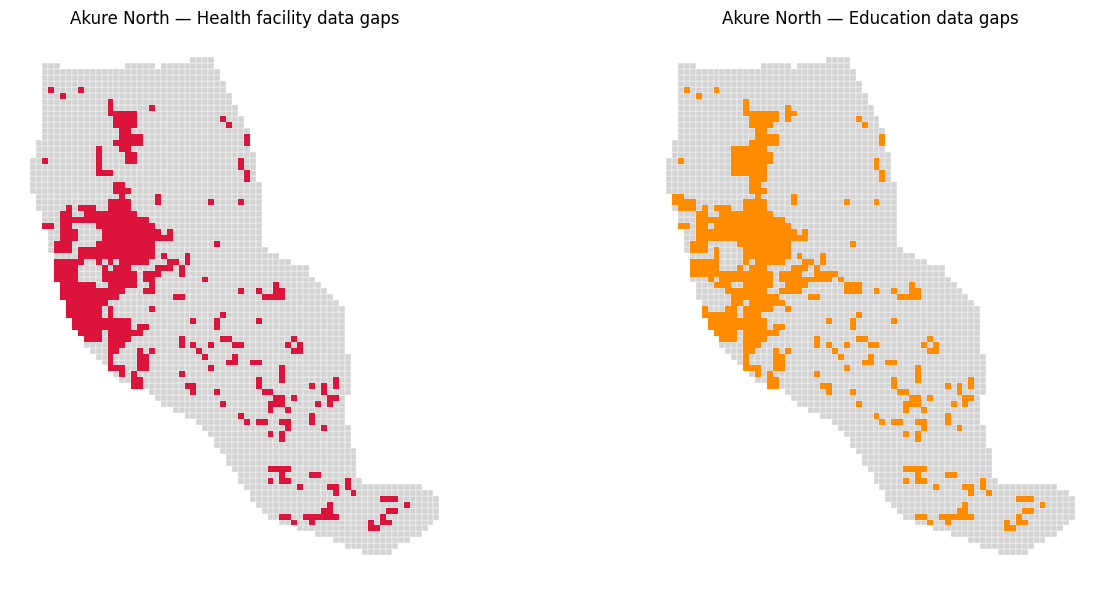

In [8]:
import matplotlib.pyplot as plt

lga_to_plot = "Akure North"
grid_to_plot = completeness_results[lga_to_plot]["grid"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

grid_to_plot.plot(ax=axes[0], color="lightgrey", edgecolor="white", linewidth=0.3)
grid_to_plot[grid_to_plot["health_completeness_flag"]].plot(ax=axes[0], color="crimson")
axes[0].set_title(f"{lga_to_plot} — Health facility data gaps")
axes[0].set_axis_off()

grid_to_plot.plot(ax=axes[1], color="lightgrey", edgecolor="white", linewidth=0.3)
grid_to_plot[grid_to_plot["education_completeness_flag"]].plot(ax=axes[1], color="darkorange")
axes[1].set_title(f"{lga_to_plot} — Education data gaps")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## 7. Export

**Outputs produced (per LGA):**

```
data/processed/{lga_name}/grid_completeness.geojson
```

Each grid cell now carries `building_count`, `health_completeness_flag`,
and `education_completeness_flag` alongside its geometry — written inside
the Section 5.1 loop, immediately after each LGA's grid is computed.

## 8. Summary

**What this notebook accomplished:** built a 500m analysis grid for both
study areas, estimated settlement presence via building density, and
flagged cells that appear settled but lack a nearby OSM-tagged health
facility or school.

**Interpretive note carried forward:** cells flagged here as data gaps
should be read as *"OSM may be under-representing this area"* rather than
*"this area has no facility."* This caveat is preserved through Notebook 03
(scoring) and surfaced explicitly in the dashboard and StoryMap narrative.

**Outputs produced:** see Section 7 above.

**Next notebook:** `03_accessibility_analysis.ipynb` builds on this grid,
adding network-based travel-time scoring across three transport modes
(walking, okada, and driving).